## 1. Environment Setup & Imports <a name='1-environment-setup'></a>

In [ ]:
# ─── Install required packages ────────────────────────────────────
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
    'imbalanced-learn', 'xgboost', 'lightgbm', 'joblib', 'tqdm'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' All packages installed.')

In [26]:
# ─── Imports ─────────────
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

# ─── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

# ─── Imbalanced-learn ────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# ─── Boosting libraries ───────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
SEED = 42

print('All imports successful.')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')
print(f'   XGBoost : {xgb.__version__}')
print(f'   LightGBM: {lgb.__version__}')

All imports successful.
   NumPy   : 2.4.2
   Pandas  : 2.3.3
   XGBoost : 3.1.2
   LightGBM: 4.6.0


## 2. Data Loading & Merging <a name='2-data-loading'></a>

**How to get the data:**
1. Download from: https://unb.ca/cic/datasets/ids-2017.html
2. Download the **MachineLearningCSV.zip** (processed feature CSV files)
3. Extract and place all CSV files in a folder named `data/`
4. Update `DATA_DIR` below if needed

**OR** use Google Drive mount if running on Colab (see cell below).

In [66]:


DATA_DIR = '/home/jovyan/imed/home/side_channel/ml_training/data/MachineLearningCVE'  # Update this path as needed


EXPECTED_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

In [67]:
# ─── Load & concatenate all CSV files ────────────────────────────────────────
def load_cicids(data_dir: str) -> pd.DataFrame:
    """Load all CSV files from data_dir into a single DataFrame."""
    csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found in: {data_dir}')
    
    frames = []
    for fname in tqdm(csv_files, desc='Loading CSVs'):
        path = os.path.join(data_dir, fname)
        df_tmp = pd.read_csv(path, encoding='utf-8', low_memory=False)
        df_tmp['source_file'] = fname   # track origin
        frames.append(df_tmp)
        print(f'  Loaded {fname:60s} → {df_tmp.shape[0]:>9,} rows')
    
    df = pd.concat(frames, axis=0, ignore_index=True)
    print(f'\n📊 Total shape after merge: {df.shape}')
    return df




DEMO_MODE = not os.path.isdir(DATA_DIR)

if DEMO_MODE:
    print('  DATA_DIR not found — running in DEMO mode with provided sample data.')
    print('    Replace the CSV string below with load_cicids(DATA_DIR) for the full run.\n')

    SAMPLE_CSV = load_cicids(DATA_DIR).head(1000).to_csv(index=False)  # Save a small sample for demo

    import io
    df = pd.read_csv(io.StringIO(SAMPLE_CSV))
    print(f'Demo dataframe shape: {df.shape}')
else:
    df = load_cicids(DATA_DIR)

Loading CSVs:  12%|█████████████████                                                                                                                       | 1/8 [00:01<00:09,  1.38s/it]

  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv         →   286,467 rows


Loading CSVs:  25%|██████████████████████████████████                                                                                                      | 2/8 [00:02<00:06,  1.04s/it]

  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv                    →   191,033 rows


Loading CSVs:  38%|███████████████████████████████████████████████████                                                                                     | 3/8 [00:03<00:05,  1.02s/it]

...

Loading CSVs:  88%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                 | 7/8 [00:14<00:02,  2.63s/it]

  Loaded Wednesday-workingHours.pcap_ISCX.csv                         →   692,703 rows


Loading CSVs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:15<00:00,  1.90s/it]

  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv       →   170,366 rows



📊 Total shape after merge: (2830743, 80)


## 3. Exploratory Data Analysis (EDA) <a name='3-eda'></a>

In [68]:
# ─── Basic information ────────────────────────────────────────────────────────
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Shape          : {df.shape}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Columns        : {df.shape[1]}')
print()
df.info(verbose=False, show_counts=True)

DATASET OVERVIEW
Shape          : (2830743, 80)
Memory usage   : 2224.3 MB
Columns        : 80

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Columns: 80 entries,  Destination Port to source_file
dtypes: float64(24), int64(54), object(2)
memory usage: 1.7+ GB


In [69]:
# ─── Display first rows ───────────────────────────────────────────────────────
df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,22,1266342,41,44,2664,6954,456,0,64.9756,109.8646,976,0,158.0455,312.6752,7595.1046,67.1225,15075.5000,104051.3997,948537,0,1266342,31658.5500,159355.2595,996324,2,317671,7387.6977,19636.4481,104616,1,0,0,0,0,1328,1424,32.3767,34.7457,0,976,111.8372,239.6868,57449.7850,0,0,0,1,0,0,0,0,1,113.1529,64.9756,158.0455,1328,0,0,0,0,0,0,41,2664,44,6954,29200,243,24,32,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...
1,22,1319353,41,44,2664,6954,456,0,64.9756,109.8646,976,0,158.0455,312.6752,7289.9368,64.4255,15706.5833,104861.8701,955790,1,1319353,32983.8250,159247.9008,996423,1,363429,8451.8372,21337.2626,104815,1,0,0,0,0,1328,1424,31.0758,33.3497,0,976,111.8372,239.6868,57449.7850,0,0,0,1,0,0,0,0,1,113.1529,64.9756,158.0455,1328,0,0,0,0,0,0,41,2664,44,6954,29200,243,24,32,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...
2,22,160,1,1,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,12500.0000,160.0000,0.0000,160,160,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,32,32,6250.0000,6250.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,0.0000,0.0000,0.0000,32,0,0,0,0,0,0,1,0,1,0,290,243,0,32,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...


In [70]:
print(len(df))

2830743


In [71]:
# ─── Identify the label column ────────────────────────────────────────────────
# The CICIDS-2017 dataset uses ' Label' (with a leading space) or 'Label'
label_col = None
for c in df.columns:
    if c.strip().lower() == 'label':
        label_col = c
        break

print(f'Label column detected: "{label_col}"')

# Rename to clean name
df.rename(columns={label_col: 'Label'}, inplace=True)
label_col = 'Label'

# Strip column names of extra whitespace
df.columns = df.columns.str.strip()

# Clean label values
df['Label'] = df['Label'].str.strip()

Label column detected: " Label"


CLASS DISTRIBUTION
                              Count  Percentage (%)
Label                                              
BENIGN                      2273097         80.3000
DoS Hulk                     231073          8.1600
PortScan                     158930          5.6100
DDoS                         128027          4.5200
DoS GoldenEye                 10293          0.3600
FTP-Patator                    7938          0.2800
SSH-Patator                    5897          0.2100
DoS slowloris                  5796          0.2000
DoS Slowhttptest               5499          0.1900
Bot                            1966          0.0700
Web Attack � Brute Force       1507          0.0500
Web Attack � XSS                652          0.0200
Infiltration                     36          0.0000
Web Attack � Sql Injection       21          0.0000
Heartbleed                       11          0.0000


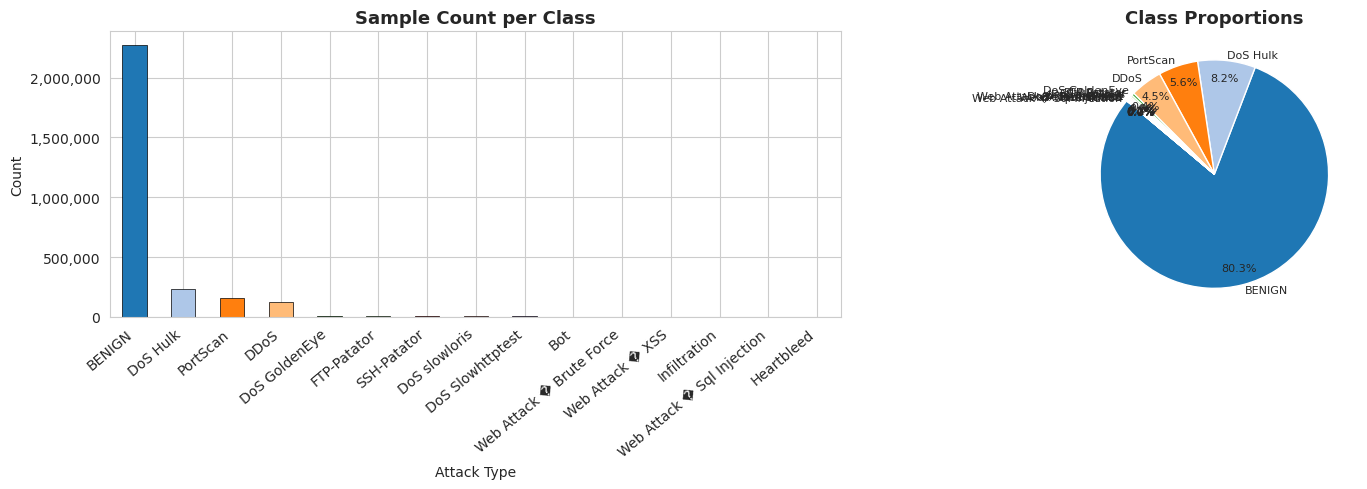

 Figure saved: class_distribution.png


In [72]:
# ─── Class distribution ───────────────────────────────────────────────────────
label_counts = df['Label'].value_counts()
label_pct    = df['Label'].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_pct.round(2)
})
print('CLASS DISTRIBUTION')
print(label_summary.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = sns.color_palette('tab20', len(label_counts))
label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Sample Count per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
label_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=140,
               colors=colors, pctdistance=0.85, labeldistance=1.05,
               textprops={'fontsize': 8})
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: class_distribution.png')

In [73]:
# ─── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print(' No missing values detected.')
else:
    print('Columns with missing values:')
    print(missing)
    
# ─── Infinite values ─────────────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
inf_counts = inf_counts[inf_counts > 0]
if inf_counts.empty:
    print('No infinite values detected.')
else:
    print('\nColumns with Infinite values:')
    print(inf_counts)

Columns with missing values:
Flow Bytes/s    1358
dtype: int64

Columns with Infinite values:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [74]:
# ─── Statistical summary of numeric features ─────────────────────────────────
numeric_df.describe().T.sort_values('std', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
Flow Duration,2830743.0000,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000
Fwd IAT Total,2830743.0000,14482961.7342,33575811.6465,0.0000,0.0000,43.0000,1242843.5000,120000000.0000
Bwd IAT Total,2830743.0000,9893830.3501,28736614.1989,0.0000,0.0000,3.0000,98580.5000,120000000.0000
Fwd IAT Max,2830743.0000,9042938.5588,24529157.3997,0.0000,0.0000,43.0000,931006.0000,120000000.0000
Flow IAT Max,2830743.0000,9182475.3171,24459539.2508,-13.0000,123.0000,30865.0000,2440145.0000,120000000.0000
Idle Max,2830743.0000,8695751.9846,24366888.3290,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Mean,2830743.0000,8316036.6272,23630078.5780,0.0000,0.0000,0.0000,0.0000,120000000.0000
Idle Min,2830743.0000,7920031.0146,23363418.9275,0.0000,0.0000,0.0000,0.0000,120000000.0000
Fwd Header Length,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000
Fwd Header Length.1,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000


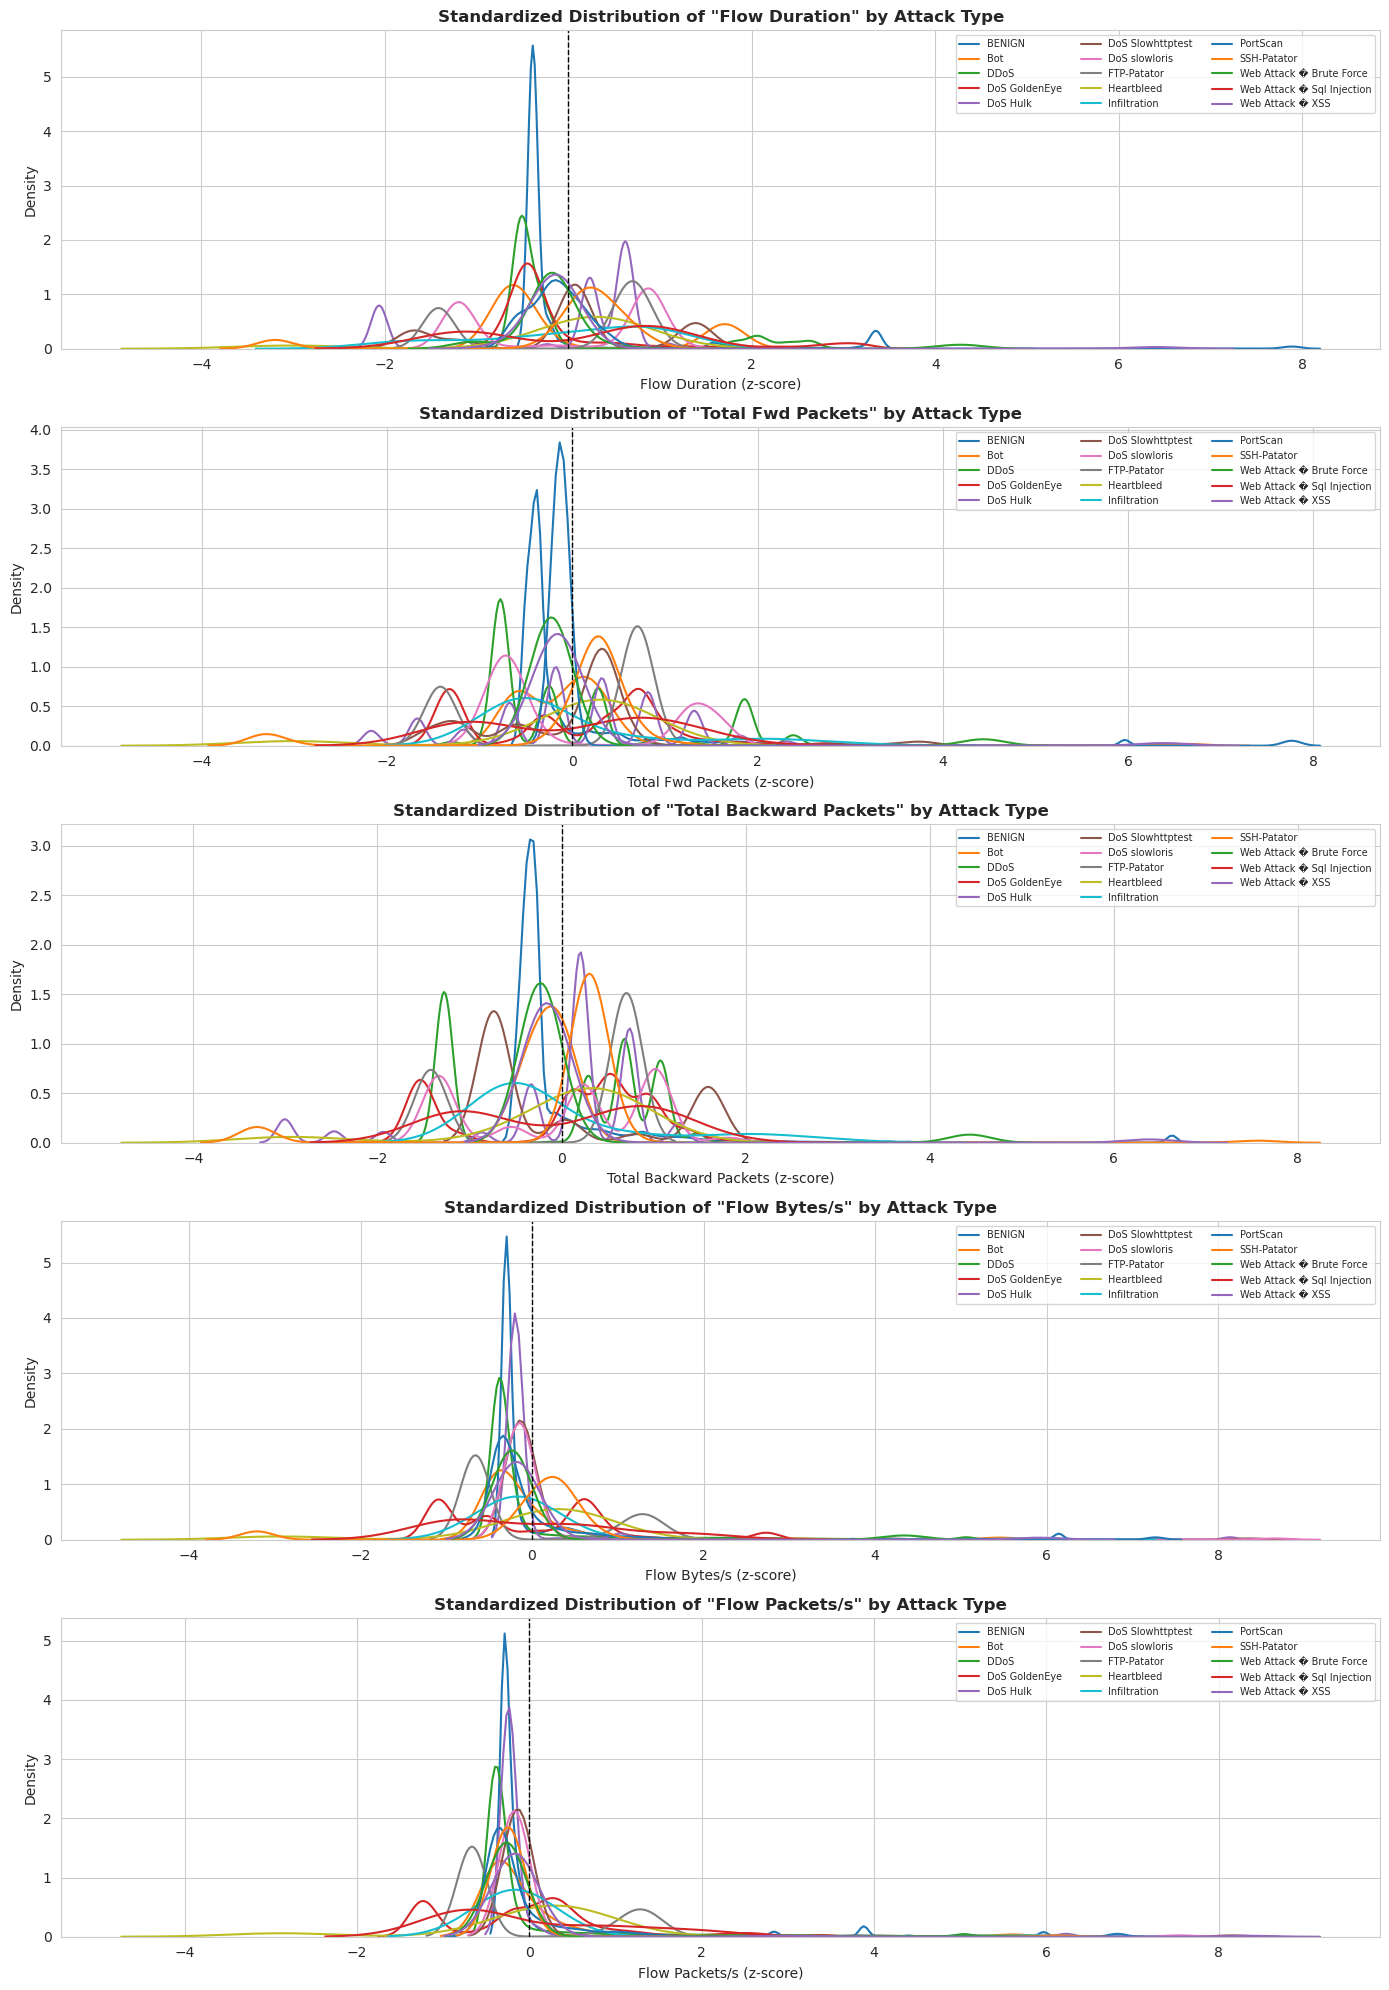

 Figure saved: feature_distributions.png


In [77]:
# ─── Distribution of top numeric features by class ───────────────────────────
PLOT_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s'
]

PLOT_FEATURES = [f for f in PLOT_FEATURES if f in df.columns]

if PLOT_FEATURES:
    fig, axes = plt.subplots(len(PLOT_FEATURES), 1, figsize=(14, 4 * len(PLOT_FEATURES)))
    if len(PLOT_FEATURES) == 1:
        axes = [axes]

    for ax, feat in zip(axes, PLOT_FEATURES):
        for label, grp in df.groupby('Label'):
            vals = grp[feat].replace([np.inf, -np.inf], np.nan).dropna()

            if len(vals) > 0 and vals.std() != 0:
                vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
                vals = (vals - vals.mean()) / vals.std()   # centered around 0
                sns.kdeplot(vals, ax=ax, label=label, fill=False, linewidth=1.5)

        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'Standardized Distribution of "{feat}" by Attack Type', fontweight='bold')
        ax.set_xlabel(f'{feat} (z-score)')
        ax.legend(fontsize=7, ncol=3)

    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Figure saved: feature_distributions.png')

## 4. Data Preprocessing & Cleaning <a name='4-preprocessing'></a>

In [76]:
# ─── 4.1 Drop non-feature columns ─────────────────────────────────────────────
COLUMNS_TO_DROP = ['source_file']   # added by loader; not a real feature
df.drop(columns=[c for c in COLUMNS_TO_DROP if c in df.columns], inplace=True)

# ─── 4.2 Replace Infinite values with NaN ────────────────────────────────────
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Rows before dropping NaN: {len(df):,}')

# ─── 4.3 Drop rows with NaN ──────────────────────────────────────────────────
df.dropna(inplace=True)
print(f'Rows after  dropping NaN: {len(df):,}')

# ─── 4.4 Remove duplicate rows ───────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'Duplicate rows          : {n_dupes:,}')
df.drop_duplicates(inplace=True)
print(f'Rows after deduplication: {len(df):,}')

Rows before dropping NaN: 2,830,743
Rows after  dropping NaN: 2,827,876
Duplicate rows          : 307,078
Rows after deduplication: 2,520,798


In [78]:
# ─── 4.5 Unify label names (whitespace / case issues in the raw dataset) ──────
LABEL_ALIASES = {
    'Web Attack  Brute Force': 'Web Attack – Brute Force',
    'Web Attack  XSS': 'Web Attack – XSS',
    'Web Attack  Sql Injection': 'Web Attack – SQL Injection',
    'Web Attack – Sql Injection': 'Web Attack – SQL Injection',
}
df['Label'] = df['Label'].replace(LABEL_ALIASES)

print('Cleaned class distribution:')
print(df['Label'].value_counts().to_string())

Cleaned class distribution:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


In [79]:
# ─── 4.6 Separate features and target ────────────────────────────────────────
X = df.drop(columns=['Label'])
y = df['Label']
print('Unique classes in y:', np.unique(y))

# Keep only numeric columns (some versions have stray string cols)
X = X.select_dtypes(include=[np.number])

print(f'Feature matrix shape : {X.shape}')
print(f'Target shape         : {y.shape}')
print(f'Number of classes    : {y.nunique()}')
print(f'Classes              : {sorted(y.unique())}')

Unique classes in y: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']
Feature matrix shape : (2520798, 78)
Target shape         : (2520798,)
Number of classes    : 15
Classes              : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [80]:
# ─── 4.7 Encode labels ────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
## print unique values of y enc
print('Unique classes in y_enc:', np.unique(y_enc))

# Build a lookup table
class_map = dict(enumerate(le.classes_))
print('Label encoding:')
for code, name in sorted(class_map.items()):
    print(f'  {code:2d} → {name}')

Unique classes in y_enc: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Label encoding:
   0 → BENIGN
   1 → Bot
   2 → DDoS
   3 → DoS GoldenEye
   4 → DoS Hulk
   5 → DoS Slowhttptest
   6 → DoS slowloris
   7 → FTP-Patator
   8 → Heartbleed
   9 → Infiltration
  10 → PortScan
  11 → SSH-Patator
  12 → Web Attack � Brute Force
  13 → Web Attack � Sql Injection
  14 → Web Attack � XSS


## 5. Feature Engineering & Selection <a name='5-feature-engineering'></a>

In [81]:
# ─── 5.1 Remove constant / near-zero-variance features ───────────────────────
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0)   # removes fully constant columns
X_vt = vt.fit_transform(X)
removed = X.columns[~vt.get_support()].tolist()
print(f'Removed {len(removed)} zero-variance features: {removed}')
X = pd.DataFrame(X_vt, columns=X.columns[vt.get_support()])
print(f'Features remaining: {X.shape[1]}')

Removed 8 zero-variance features: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Features remaining: 70


In [82]:
# ─── 5.2 Correlation analysis — remove highly correlated pairs ───────────────
CORR_THRESHOLD = 0.98

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

print(f'Features with correlation > {CORR_THRESHOLD}: {len(to_drop_corr)}')
print(to_drop_corr)
X.drop(columns=to_drop_corr, inplace=True)
print(f'Features remaining after corr filter: {X.shape[1]}')

Features with correlation > 0.98: 20
['Total Backward Packets', 'Total Length of Bwd Packets', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Max', 'Idle Min']
Features remaining after corr filter: 50


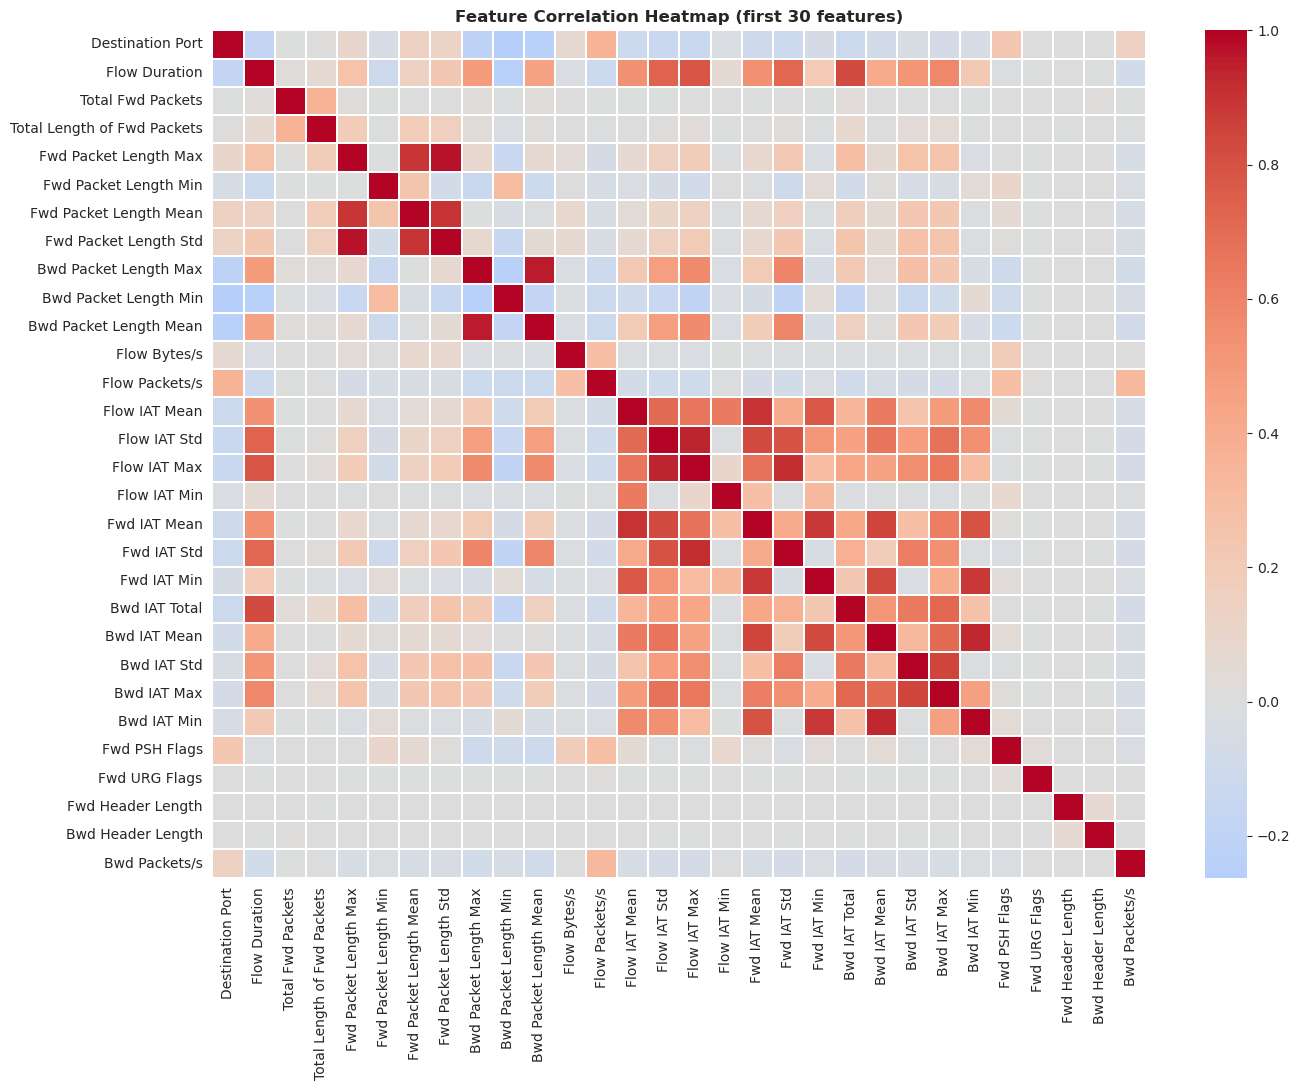

 Figure saved: correlation_heatmap.png


In [83]:
# ─── 5.3 Correlation heatmap ─────────────────────────────────────────────────
# Show heatmap of remaining features (sampled to 30 for legibility)
sample_feats = X.columns[:30].tolist()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(X[sample_feats].corr(), ax=ax, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
ax.set_title('Feature Correlation Heatmap (first 30 features)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: correlation_heatmap.png')

Computing feature importances via ExtraTrees (this may take a minute)…


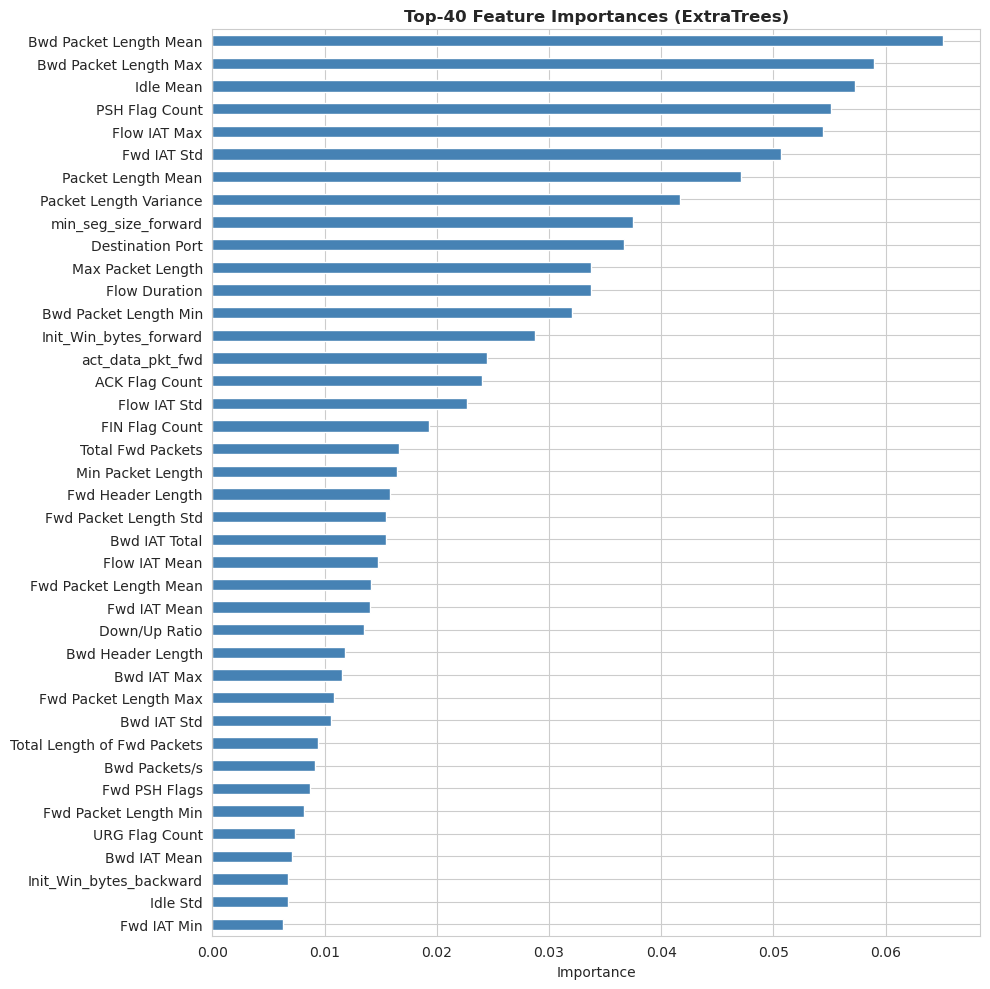

 Figure saved: feature_importance.png


In [84]:
# ─── 5.4 Feature importance via Extra-Trees (fast, handles multiclass) ────────
print('Computing feature importances via ExtraTrees (this may take a minute)…')
et = ExtraTreesClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
et.fit(X, y_enc)

feat_imp = pd.Series(et.feature_importances_, index=X.columns)\
             .sort_values(ascending=False)

TOP_K = 40
fig, ax = plt.subplots(figsize=(10, 10))
feat_imp.head(TOP_K).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top-{TOP_K} Feature Importances (ExtraTrees)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: feature_importance.png')

In [97]:
# ─── 5.5 Keep only top-N most important features ─────────────────────────────
N_FEATURES = 50   # adjust as needed; more = better accuracy, slower training
TOP_FEATURES = feat_imp.head(N_FEATURES).index.tolist()

X_selected = X[TOP_FEATURES].copy()
print(f'Selected {N_FEATURES} features for modelling.')
print(TOP_FEATURES[:10], '...')

Selected 50 features for modelling.
['Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Idle Mean', 'PSH Flag Count', 'Flow IAT Max', 'Fwd IAT Std', 'Packet Length Mean', 'Packet Length Variance', 'min_seg_size_forward', 'Destination Port'] ...


## 6. Handling Class Imbalance <a name='6-class-imbalance'></a>

In [98]:
# ─── Train / Test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_enc,
    test_size=0.20,
    random_state=SEED,
    stratify=y_enc
)
print(f'Train set : {X_train.shape[0]:,} samples')
print(f'Test  set : {X_test.shape[0]:,} samples')
## print unique values of y train
print('Unique classes in y_train:', np.unique(y_train))

Train set : 2,016,638 samples
Test  set : 504,160 samples
Unique classes in y_train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


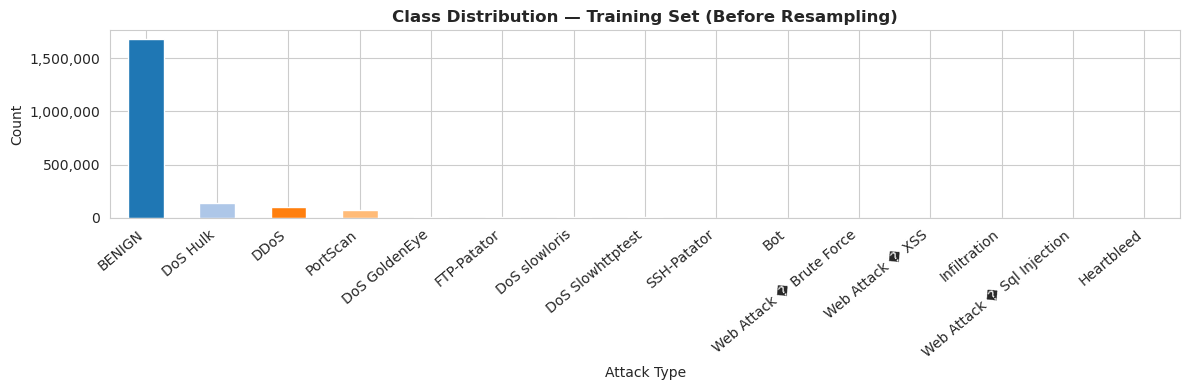

In [99]:
# ─── 6.1 Visualise class imbalance in train set ───────────────────────────────
train_label_counts = pd.Series(y_train).map(class_map).value_counts()

fig, ax = plt.subplots(figsize=(12, 4))
train_label_counts.plot(kind='bar', ax=ax, color=sns.color_palette('tab20', len(train_label_counts)))
ax.set_title('Class Distribution — Training Set (Before Resampling)', fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Attack Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('class_imbalance_train.png', dpi=150, bbox_inches='tight')
plt.show()

In [100]:
# ─── 6.2 Resampling strategy ──────────────────────────────────────────────────
# We use class_weight='balanced' inside tree-based models (no explicit resample)
# For models that don't support it, we use SMOTE on training data only.

# Compute class weights for use in model params
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('Sample class weights (first 5):', dict(list(class_weight_dict.items())[:5]))

# Scale features (needed for LR, SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Sample class weights (first 5): {np.int64(0): np.float64(0.08021415495009582), np.int64(1): np.float64(86.29174154899444), np.int64(2): np.float64(1.3127743439018595), np.int64(3): np.float64(16.3376513954713), np.int64(4): np.float64(0.9722696712637194)}


## 7. Model Training <a name='7-model-training'></a>

We train **7 classifiers** and compare their performance:

| # | Model | Notes |
|---|-------|-------|
| 1 | Decision Tree | Fast baseline |
| 2 | Random Forest | Strong ensemble |
| 3 | Extra Trees | Faster RF variant |
| 4 | XGBoost | Gradient boosting |
| 5 | LightGBM | Fast gradient boosting |
| 6 | Logistic Regression | Linear baseline |
| 7 | K-Nearest Neighbours | Non-parametric |

In [101]:
# ─── Model definitions ────────────────────────────────────────────────────────
N_CLASSES = len(le.classes_)

models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=20,
        class_weight='balanced',
        random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=N_CLASSES,
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
}

In [102]:
# ─── Train all models (GPU-enabled when possible) ─────────────────────────────

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score

# Check GPU availability (informational only for sklearn models)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Models that need scaled data
SCALED_MODELS = {'Logistic Regression', 'KNN'}

results = {}

for name, model in models.items():
    print(f'\n▶ Training: {name}…')

    # Select appropriate dataset version
    X_tr = X_train_scaled if name in SCALED_MODELS else X_train
    X_te = X_test_scaled  if name in SCALED_MODELS else X_test

    # XGBoost requires int labels
    y_tr = y_train.astype(np.int32) if name == 'XGBoost' else y_train

    # Fit model
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_te)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_macro': f1_m,
        'f1_weighted': f1_w,
        'scaled': name in SCALED_MODELS,
        'device': device
    }

    print(f'   Accuracy: {acc:.4f} | F1-macro: {f1_m:.4f} | F1-weighted: {f1_w:.4f}')

print('\n✔ All models trained.')

Using device: cuda

▶ Training: Decision Tree…


   Accuracy: 0.9967 | F1-macro: 0.8740 | F1-weighted: 0.9974

▶ Training: Random Forest…
   Accuracy: 0.9983 | F1-macro: 0.8670 | F1-weighted: 0.9983

▶ Training: Extra Trees…
   Accuracy: 0.9980 | F1-macro: 0.8615 | F1-weighted: 0.9980

▶ Training: XGBoost…
   Accuracy: 0.9987 | F1-macro: 0.8770 | F1-weighted: 0.9987

▶ Training: LightGBM…
   Accuracy: 0.5145 | F1-macro: 0.1610 | F1-weighted: 0.6176

▶ Training: Logistic Regression…
   Accuracy: 0.8407 | F1-macro: 0.4937 | F1-weighted: 0.8912

▶ Training: KNN…
   Accuracy: 0.9944 | F1-macro: 0.8116 | F1-weighted: 0.9944

✔ All models trained.


In [110]:
from sklearn.metrics import classification_report

print("\n════════ Classification Reports ════════")

for name, res in results.items():
    print(f"\n▶ Model: {name}")
    print("--------------------------------------------------")
    
    y_pred = res['y_pred']
    
    print(classification_report(
        y_test,
        y_pred,
        digits=4,
        zero_division=0
    ))


════════ Classification Reports ════════

▶ Model: Decision Tree
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9998    0.9967    0.9983    419012
           1     0.2669    0.9846    0.4199       390
           2     0.9996    1.0000    0.9998     25603
           3     0.9879    0.9937    0.9908      2057
           4     0.9982    0.9994    0.9988     34569
           5     0.9820    0.9904    0.9862      1046
           6     0.9806    0.9861    0.9833      1077
           7     0.9992    0.9992    0.9992      1186
           8     1.0000    1.0000    1.0000         2
           9     1.0000    0.8571    0.9231         7
          10     0.9884    0.9975    0.9929     18139
          11     0.9984    1.0000    0.9992       644
          12     0.7614    0.6837    0.7204       294
          13     0.5000    0.7500    0.6000         4
          14     0.4431    0.5692    0.4983       130

    accuracy     

## 8. Model Evaluation & Comparison <a name='8-evaluation'></a>

In [111]:
# ─── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {
        'Accuracy'     : v['accuracy'],
        'F1 Macro'     : v['f1_macro'],
        'F1 Weighted'  : v['f1_weighted'],
    }
    for name, v in results.items()
}).T.sort_values('F1 Macro', ascending=False)

print('MODEL COMPARISON SUMMARY')
print(summary.to_string())
summary

MODEL COMPARISON SUMMARY
                     Accuracy  F1 Macro  F1 Weighted
XGBoost                0.9987    0.8770       0.9987
Decision Tree          0.9967    0.8740       0.9974
Random Forest          0.9983    0.8670       0.9983
Extra Trees            0.9980    0.8615       0.9980
KNN                    0.9944    0.8116       0.9944
Logistic Regression    0.8407    0.4937       0.8912
LightGBM               0.5145    0.1610       0.6176


,Accuracy,F1 Macro,F1 Weighted
XGBoost,0.9987,0.8770,0.9987
Decision Tree,0.9967,0.8740,0.9974
Random Forest,0.9983,0.8670,0.9983
Extra Trees,0.9980,0.8615,0.9980
KNN,0.9944,0.8116,0.9944
Logistic Regression,0.8407,0.4937,0.8912
LightGBM,0.5145,0.1610,0.6176


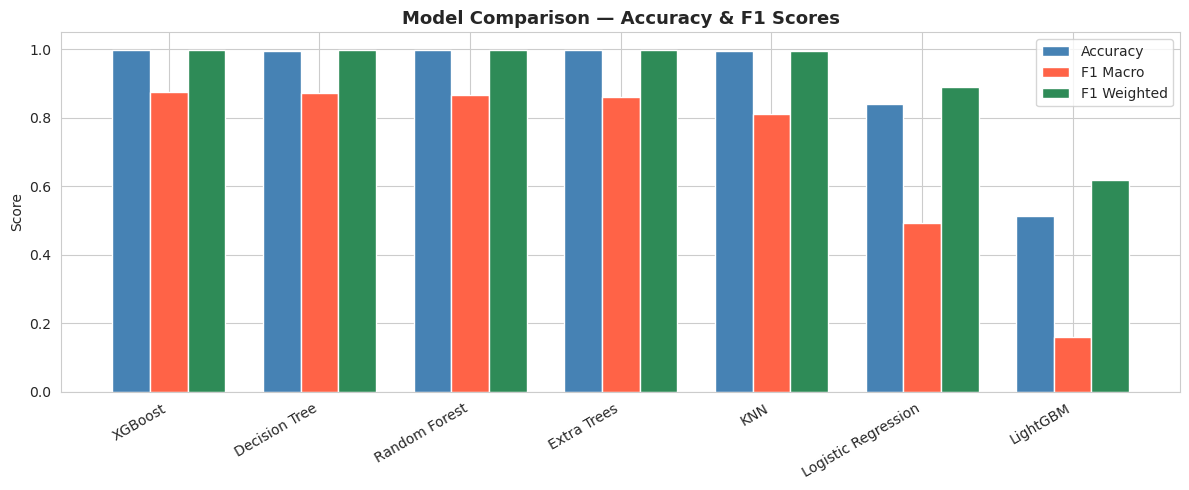

 Figure saved: model_comparison.png


In [112]:
# ─── Bar chart — model comparison ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary))
w = 0.25

ax.bar(x - w, summary['Accuracy'],    width=w, label='Accuracy',    color='steelblue')
ax.bar(x,     summary['F1 Macro'],    width=w, label='F1 Macro',    color='tomato')
ax.bar(x + w, summary['F1 Weighted'], width=w, label='F1 Weighted', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Accuracy & F1 Scores', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: model_comparison.png')

In [113]:
# ─── Classification report for every model ───────────────────────────────────
for name, v in results.items():
    print('='*70)
    print(f'  {name}')
    print('='*70)
    print(classification_report(
        y_test, v['y_pred'],
        target_names=le.classes_,
        zero_division=0
    ))

  Decision Tree
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.27      0.98      0.42       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.98      0.99      0.99      1046
             DoS slowloris       0.98      0.99      0.98      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack � Brute Force       0.76      0.68      0.72       294
Web Attack � Sql Injection     

## 9. Best Model — Deep Dive <a name='9-best-model'></a>

In [114]:
# ─── Select best model by F1-macro ───────────────────────────────────────────
best_name = summary['F1 Macro'].idxmax()
best_result = results[best_name]
best_model  = best_result['model']

print(f'Best model: {best_name}')
print(f'   Accuracy   : {best_result["accuracy"]:.4f}')
print(f'   F1 Macro   : {best_result["f1_macro"]:.4f}')
print(f'   F1 Weighted: {best_result["f1_weighted"]:.4f}')

Best model: XGBoost
   Accuracy   : 0.9987
   F1 Macro   : 0.8770
   F1 Weighted: 0.9987


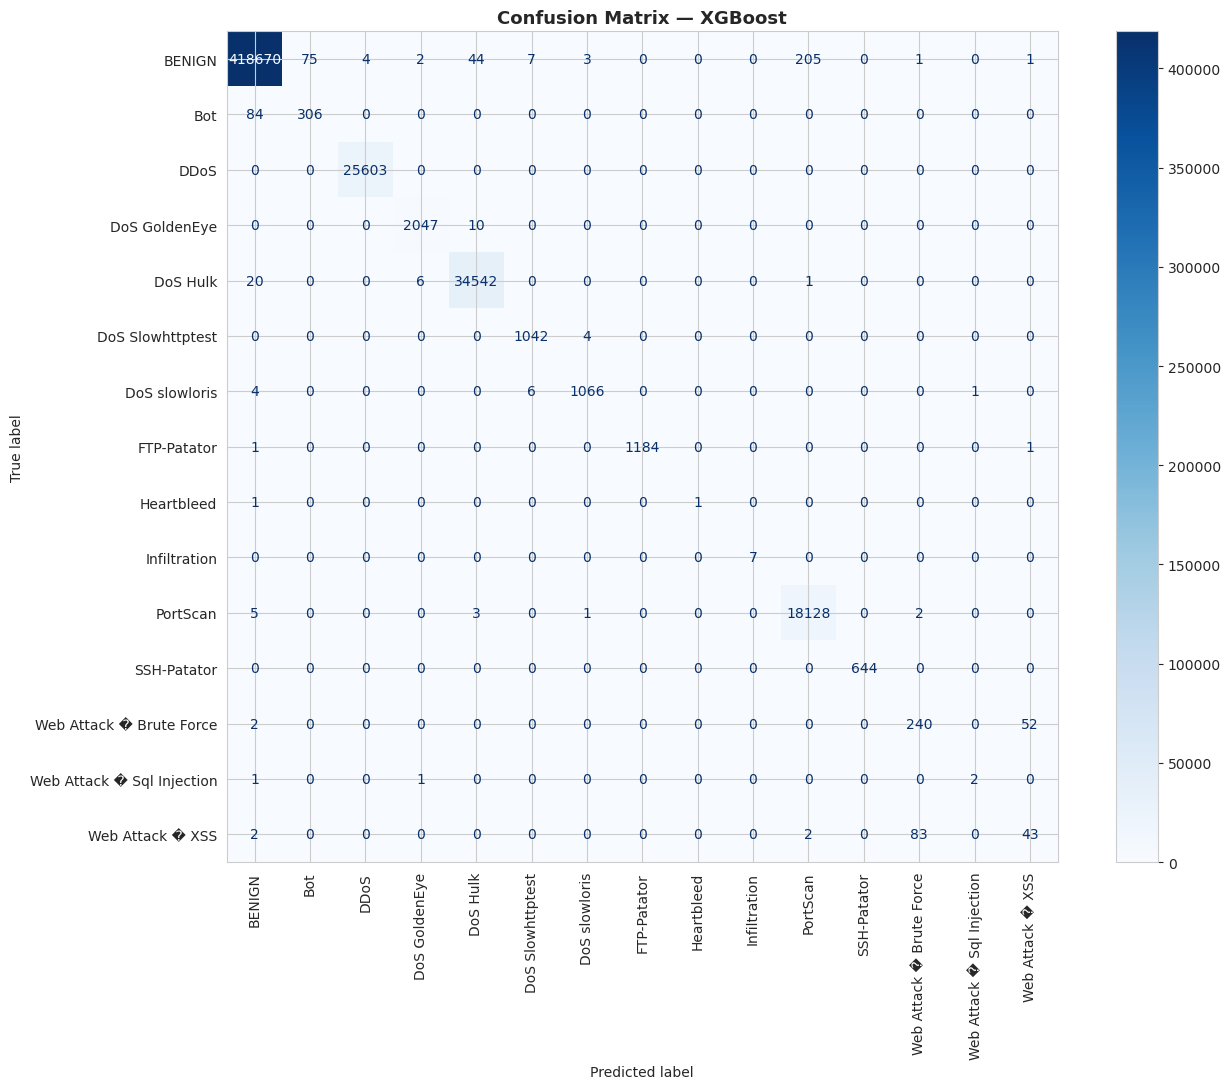

 Figure saved: confusion_matrix.png


In [115]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
y_pred_best = best_result['y_pred']
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(14, 11))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d',
          xticks_rotation='vertical')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: confusion_matrix.png')

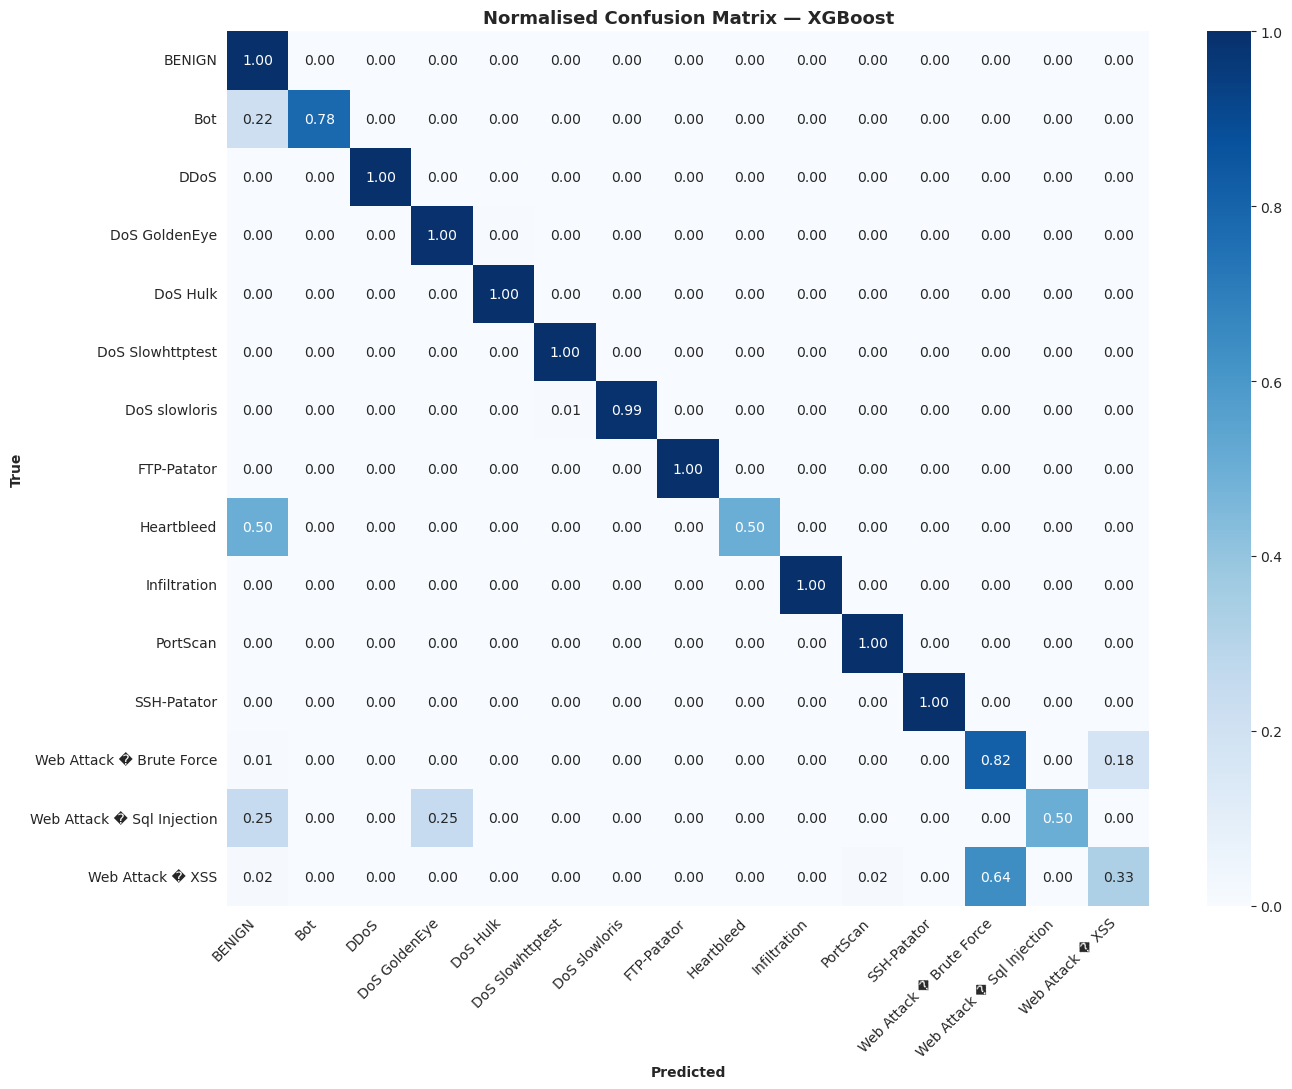

 Figure saved: confusion_matrix_normalised.png


In [116]:
# ─── Normalised Confusion Matrix (recall per class) ──────────────────────────
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title(f'Normalised Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: confusion_matrix_normalised.png')

                            Precision  Recall  F1-Score  Support
BENIGN                         0.9997  0.9992    0.9994   419012
Bot                            0.8031  0.7846    0.7938      390
DDoS                           0.9998  1.0000    0.9999    25603
DoS GoldenEye                  0.9956  0.9951    0.9954     2057
DoS Hulk                       0.9984  0.9992    0.9988    34569
DoS Slowhttptest               0.9877  0.9962    0.9919     1046
DoS slowloris                  0.9926  0.9898    0.9912     1077
FTP-Patator                    1.0000  0.9983    0.9992     1186
Heartbleed                     1.0000  0.5000    0.6667        2
Infiltration                   1.0000  1.0000    1.0000        7
PortScan                       0.9887  0.9994    0.9940    18139
SSH-Patator                    1.0000  1.0000    1.0000      644
Web Attack � Brute Force       0.7362  0.8163    0.7742      294
Web Attack � Sql Injection     0.6667  0.5000    0.5714        4
Web Attack � XSS         

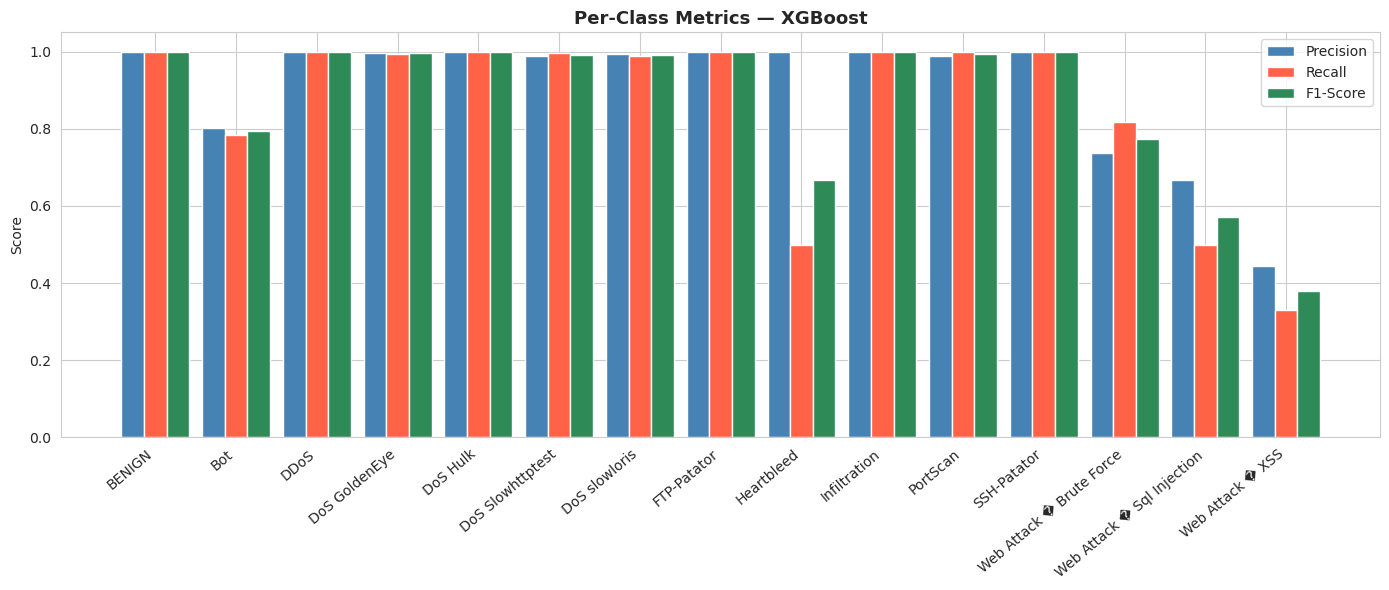

Figure saved: per_class_metrics.png


In [118]:
# ─── Per-class precision / recall / F1 bar chart ─────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, y_pred_best, labels=range(N_CLASSES), zero_division=0
)

per_class_df = pd.DataFrame({
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'Support'  : sup,
}, index=le.classes_)

print(per_class_df.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(N_CLASSES)
w = 0.28

ax.bar(x - w, per_class_df['Precision'], w, label='Precision', color='steelblue')
ax.bar(x,     per_class_df['Recall'],    w, label='Recall',    color='tomato')
ax.bar(x + w, per_class_df['F1-Score'],  w, label='F1-Score',  color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=40, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-Class Metrics — {best_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: per_class_metrics.png')

## 10. Attack Type Visualization <a name='10-visualization'></a>

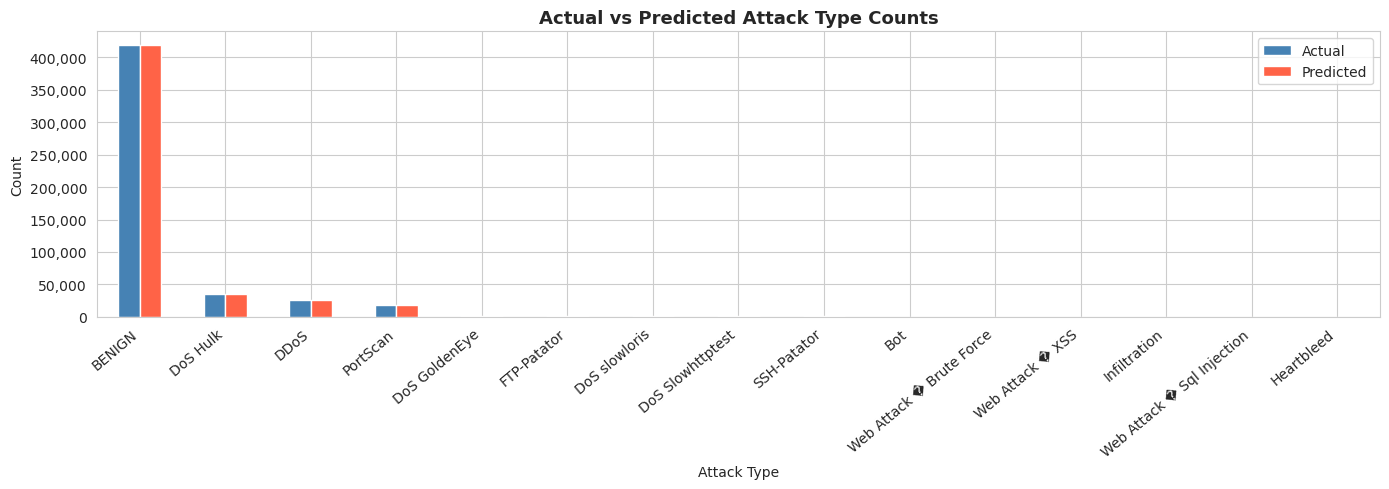

In [119]:
# ─── 10.1 Actual vs Predicted attack distribution on test set ─────────────────
true_dist = pd.Series(y_test).map(class_map).value_counts()
pred_dist = pd.Series(y_pred_best).map(class_map).value_counts()

compare_df = pd.DataFrame({'Actual': true_dist, 'Predicted': pred_dist}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
compare_df.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Actual vs Predicted Attack Type Counts', fontsize=13, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

Computing PCA 2D projection (may take a moment)…


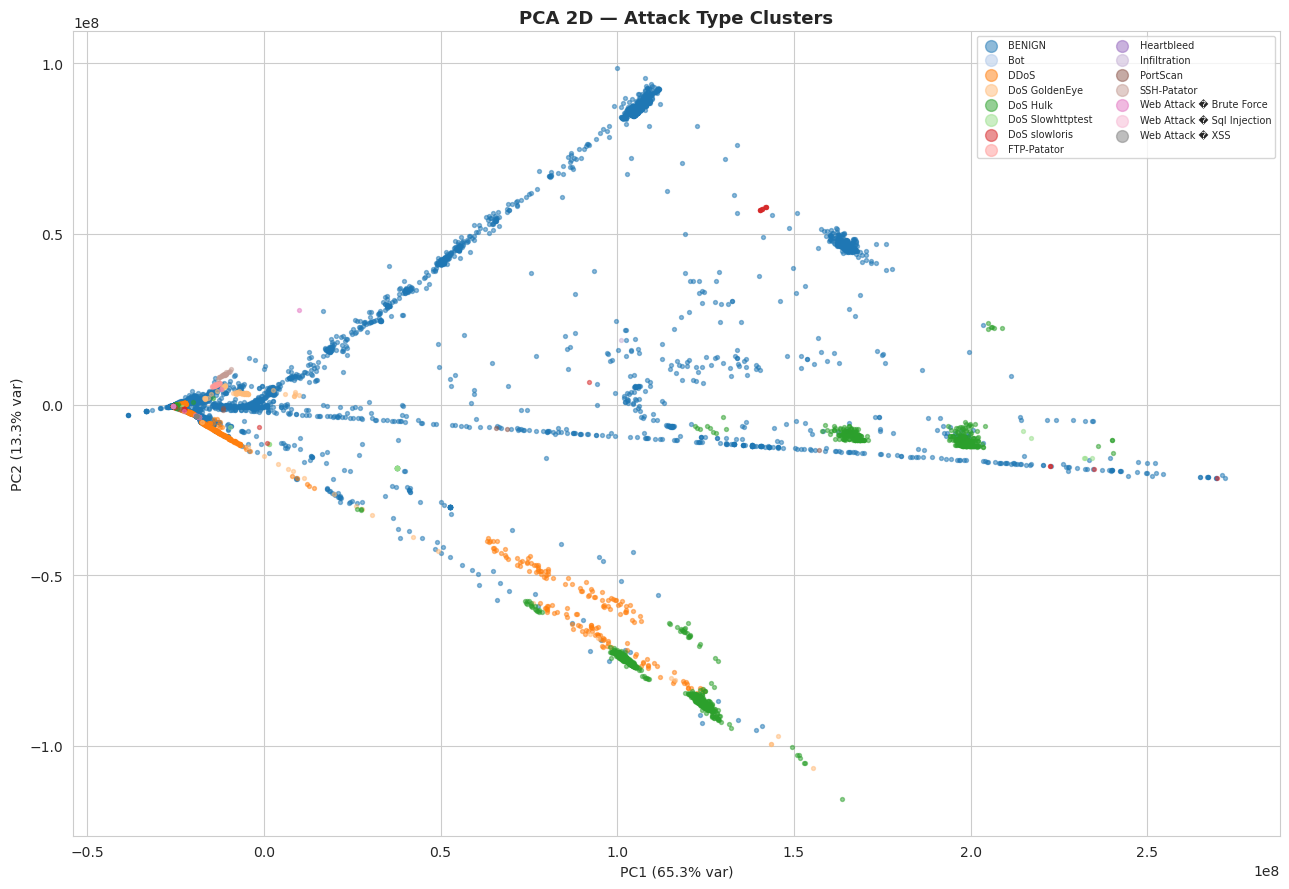

 Figure saved: pca_clusters.png


In [120]:
# ─── 10.2 PCA 2D visualisation of attack clusters ────────────────────────────
print('Computing PCA 2D projection (may take a moment)…')

# Sample up to 20k points for speed
N_SAMPLE = min(20_000, len(X_test))
idx = np.random.default_rng(SEED).choice(len(X_test), N_SAMPLE, replace=False)

X_pca_input = X_test_scaled[idx] if best_result['scaled'] else X_test.values[idx]
y_pca = y_test[idx]

pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_pca_input)

pca_df = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
pca_df['Label'] = pd.Series(y_pca).values
pca_df['Label_name'] = pca_df['Label'].map(class_map)

palette = sns.color_palette('tab20', N_CLASSES)
fig, ax = plt.subplots(figsize=(13, 9))
for code, name in class_map.items():
    mask = pca_df['Label'] == code
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               s=8, alpha=0.5, color=palette[code % 20], label=name)

ax.set_title('PCA 2D — Attack Type Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(fontsize=7, ncol=2, markerscale=3)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: pca_clusters.png')

Total misclassified: 635 / 504,160 (0.13%)


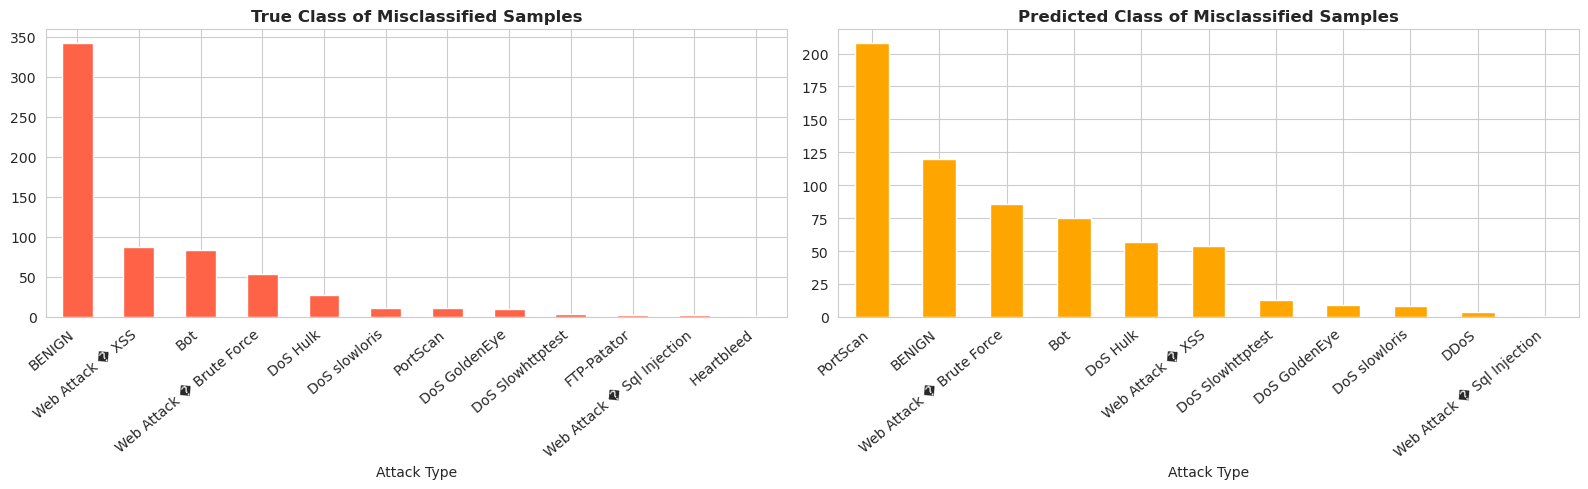

In [121]:
# ─── 10.3 Misclassification analysis ──────────────────────────────────────────
misclassified_mask = y_test != y_pred_best
n_misclassified = misclassified_mask.sum()
print(f'Total misclassified: {n_misclassified:,} / {len(y_test):,} ({100*n_misclassified/len(y_test):.2f}%)')

# Where are errors concentrated?
error_true  = pd.Series(y_test[misclassified_mask]).map(class_map).value_counts()
error_pred  = pd.Series(y_pred_best[misclassified_mask]).map(class_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

error_true.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('True Class of Misclassified Samples', fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')

error_pred.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Predicted Class of Misclassified Samples', fontweight='bold')
axes[1].set_xlabel('Attack Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig('misclassification_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
# ─── 10.4 Attack type timeline summary (requires source_file or timestamp) ────
# This shows per-file attack distribution if source_file exists

# Rebuild a summary dataframe from full dataset
attack_summary = df.groupby('Label').size().reset_index(name='count')
attack_summary['percentage'] = 100 * attack_summary['count'] / attack_summary['count'].sum()
attack_summary = attack_summary.sort_values('count', ascending=False)

print('\nFINAL ATTACK TYPE SUMMARY:')
print('='*55)
for _, row in attack_summary.iterrows():
    bar = '█' * int(row['percentage'] / 2)
    print(f'  {row["Label"]:40s} {row["count"]:>9,}  ({row["percentage"]:5.2f}%)  {bar}')
print('='*55)


FINAL ATTACK TYPE SUMMARY:
  BENIGN                                   2,095,057  (83.11%)  █████████████████████████████████████████
  DoS Hulk                                   172,846  ( 6.86%)  ███
  DDoS                                       128,014  ( 5.08%)  ██
  PortScan                                    90,694  ( 3.60%)  █
  DoS GoldenEye                               10,286  ( 0.41%)  
  FTP-Patator                                  5,931  ( 0.24%)  
  DoS slowloris                                5,385  ( 0.21%)  
  DoS Slowhttptest                             5,228  ( 0.21%)  
  SSH-Patator                                  3,219  ( 0.13%)  
  Bot                                          1,948  ( 0.08%)  
  Web Attack � Brute Force                     1,470  ( 0.06%)  
  Web Attack � XSS                               652  ( 0.03%)  
  Infiltration                                    36  ( 0.00%)  
  Web Attack � Sql Injection                      21  ( 0.00%)  
  Heartbleed   

## 11. Save & Export Best Model <a name='11-save-model'></a>

In [123]:
# ─── Save model, scaler, encoder, feature list ───────────────────────────────
os.makedirs('saved_model', exist_ok=True)

artifacts = {
    'model'         : best_model,
    'scaler'        : scaler,
    'label_encoder' : le,
    'features'      : TOP_FEATURES,
    'best_model_name': best_name,
    'class_map'     : class_map,
}

joblib.dump(artifacts, 'saved_model/ids_pipeline.pkl', compress=3)
print(' Model artifacts saved to: saved_model/ids_pipeline.pkl')

# Save class summary CSV
per_class_df.to_csv('saved_model/per_class_metrics.csv')
summary.to_csv('saved_model/model_comparison.csv')
print('Metrics CSVs saved to saved_model/')

 Model artifacts saved to: saved_model/ids_pipeline.pkl
Metrics CSVs saved to saved_model/


## 12. Inference on New Data <a name='12-inference'></a>

Use the cells below to load the saved pipeline and classify new network flows.

In [124]:
# ─── Load saved artifacts ─────────────────────────────────────────────────────
loaded = joblib.load('saved_model/ids_pipeline.pkl')

model_inf   = loaded['model']
scaler_inf  = loaded['scaler']
le_inf      = loaded['label_encoder']
features_inf= loaded['features']
class_map_inf = loaded['class_map']

print(f' Loaded model: {loaded["best_model_name"]}')
print(f'   Expected features ({len(features_inf)}): {features_inf[:5]}…')

 Loaded model: XGBoost
   Expected features (50): ['Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Idle Mean', 'PSH Flag Count', 'Flow IAT Max']…


In [125]:
# ─── Prediction function ──────────────────────────────────────────────────────
def predict_attack_type(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Classify network flows.

    Parameters
    ----------
    raw_df : pd.DataFrame
        DataFrame with the same columns as the training data (Label column optional).

    Returns
    -------
    pd.DataFrame with columns: predicted_code, predicted_label, confidence
    """
    # Strip whitespace from column names
    raw_df = raw_df.copy()
    raw_df.columns = raw_df.columns.str.strip()

    # Keep only expected features
    missing_feats = [f for f in features_inf if f not in raw_df.columns]
    if missing_feats:
        raise ValueError(f'Missing features: {missing_feats}')

    X_new = raw_df[features_inf].copy()
    X_new = X_new.select_dtypes(include=[np.number])
    X_new.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_new.fillna(0, inplace=True)

    # Scale if needed
    if loaded['best_model_name'] in SCALED_MODELS:
        X_new_arr = scaler_inf.transform(X_new)
    else:
        X_new_arr = X_new.values

    codes = model_inf.predict(X_new_arr)
    labels = le_inf.inverse_transform(codes)

    # Confidence (probability of top class)
    if hasattr(model_inf, 'predict_proba'):
        proba = model_inf.predict_proba(X_new_arr)
        conf = proba.max(axis=1)
    else:
        conf = np.ones(len(codes))

    return pd.DataFrame({
        'predicted_code' : codes,
        'predicted_label': labels,
        'confidence'     : conf,
    })


print(' predict_attack_type() function ready.')

 predict_attack_type() function ready.


In [126]:
# ─── Demo prediction on a few test samples ───────────────────────────────────
# Rebuild X_test as a DataFrame for the function
X_test_df = pd.DataFrame(X_test.values if not isinstance(X_test, pd.DataFrame) else X_test,
                          columns=TOP_FEATURES)

sample = X_test_df.head(10).copy()
preds  = predict_attack_type(sample)

# Add true labels for comparison
preds['true_label'] = le.inverse_transform(y_test[:10])
preds['correct']    = preds['predicted_label'] == preds['true_label']

print('\nSample predictions (first 10 test flows):')
print(preds[['true_label', 'predicted_label', 'confidence', 'correct']].to_string())


Sample predictions (first 10 test flows):
  true_label predicted_label  confidence  correct
0     BENIGN          BENIGN      1.0000     True
1   PortScan        PortScan      0.9371     True
2     BENIGN          BENIGN      1.0000     True
3     BENIGN          BENIGN      1.0000     True
4     BENIGN          BENIGN      1.0000     True
5     BENIGN          BENIGN      1.0000     True
6     BENIGN          BENIGN      1.0000     True
7       DDoS            DDoS      1.0000     True
8     BENIGN          BENIGN      0.9999     True
9     BENIGN          BENIGN      1.0000     True


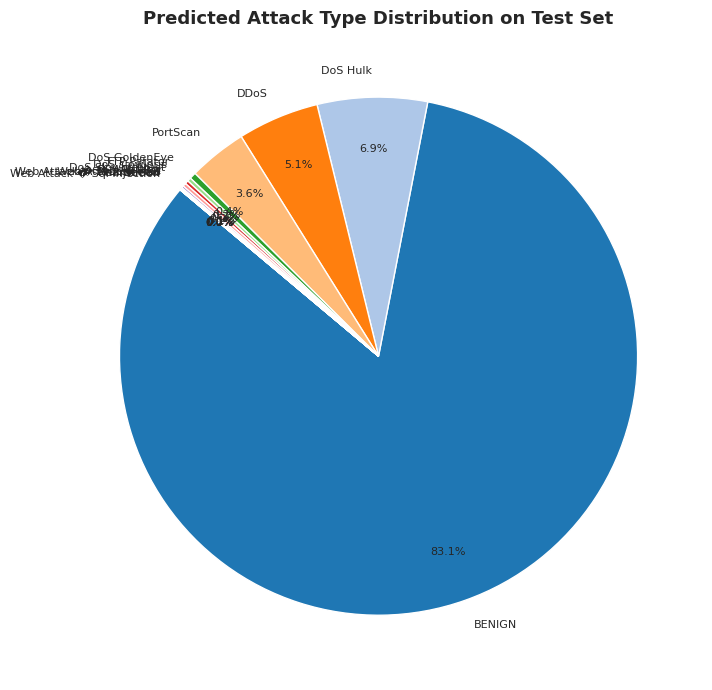

 Figure saved: predicted_distribution.png


In [127]:
# ─── Final prediction distribution pie chart ──────────────────────────────────
all_preds = predict_attack_type(X_test_df)
pred_counts = all_preds['predicted_label'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    pred_counts.values,
    labels=pred_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    colors=sns.color_palette('tab20', len(pred_counts)),
    textprops={'fontsize': 8}
)
ax.set_title('Predicted Attack Type Distribution on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure saved: predicted_distribution.png')

---

##  Summary

This notebook delivers a **complete Network Intrusion Detection System** pipeline:

| Step | What was done |
|------|---------------|
| Data Loading | Merged all 8 daily CSV files from CICIDS-2017 |
| EDA | Class distribution, missing/infinite values, feature distributions |
| Preprocessing | Cleaned labels, dropped NaN/Inf/duplicates |
| Feature Engineering | Variance filter, correlation filter, ExtraTrees importance |
| Class Imbalance | `class_weight='balanced'` in tree models; StandardScaler for linear models |
| Training | 7 classifiers: DT, RF, ExtraTrees, XGBoost, LightGBM, LR, KNN |
| Evaluation | Accuracy, F1-macro, F1-weighted, confusion matrix, per-class metrics |
| Visualization | PCA clusters, misclassification analysis, predicted distribution |
| Saving | Best model + scaler + encoder exported as `saved_model/ids_pipeline.pkl` |
| Inference | `predict_attack_type()` function ready for real-time use |

###  Next Steps
- **Hyperparameter tuning**: use `Optuna` or `GridSearchCV` on the best model
- **SHAP explanations**: `shap.TreeExplainer` to understand individual predictions
- **Real-time deployment**: wrap `predict_attack_type()` in a FastAPI endpoint
- **Feature engineering**: add packet rate ratios, temporal aggregations
- **Deep learning**: try a 1D CNN or LSTM on packet sequences